# Demo: Mapping Luhman 16B with NIRSpec

In this tutorial, we will demonstrate how to use `spectralmap` to analyze time-series observations. We will use a sequence of NIRSpec observations of the brown dwarf Luhman 16B to recover a spectroscopic map of its surface.

**We will cover:**
1. Loading and preprocessing the lightcurve data.
2. Inverting the lightcurves to obtain surface maps.
3. Clustering the map pixels to identify distinct spectral regions.
4. Extracting and analyzing the spectra of these regions.

Let's get started!

## 1. Load Data
We load the NIRSpec lightcurve files. Each file corresponds to a specific rotation phase (angle). We will read them in, sort them by phase, and normalize the flux.

In [1]:
import numpy as np
from spectralmap.utilities import bin_flux_by_theta, bin_flux

# 1. Load the data files
data_file = "data/Luhman16B_NIRSpec_2023.npz"
theta = np.load(data_file)["theta"]

wl = np.load(data_file)["wl"]
flux_raw = np.load(data_file)["flux_raw"]
theta, flux_raw, flux_err, counts = bin_flux(theta, flux_raw, n_bins=64, flux_err=None)
time = theta / 360.0 * 5.0  # Convert theta to time (we previously assumed a 5-hour rotation period when computing theta)

/Users/ruizhewang/miniconda3/envs/spectralmap/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


## 2. Inversion with SpectralMap

First, we organize the data into a `LightCurveData` object.

In [2]:
from spectralmap.core import LightCurveData
data = LightCurveData(theta=theta, time=time, flux=flux_raw, flux_err=None, wl=wl)

### Applying wavelength-dependent limb darkening coeffcients
These precomputed limb darkening coeffcients were fitted using a quadratic profile on 3D spectra calculated by PICASO. If those are not available, we can use a wavelength-indepdent limb-darkening profile, or disable limb-darkening altogether.

In [ ]:
# Read precomputed quadratic limb-darkening coefficients and interpolate to data wavelengths
from spectralmap.utilities import load_quadratic_limb_darkening

u_wl = load_quadratic_limb_darkening("data/S0136_quadratic_limb_darkening_coeffs.csv", wl)

# continue with maps creation
simp_maps = make_maps(map_res=30, u=u_wl, verbose=True)
simp_maps.marginalize(simp_data, ydeg=np.arange(2, 8), inc=[70, 80, 90], prot=None)

### Marginalize over model complexities and physical parameters
We now solve for the posterior distribution of the maps. Since we don't know the optimal model or exact inclination/rotational period beforehand, we marginalize over these parameters. This can be done by providing a prior dictionary, list or array of values, or just a single value.

In [4]:
ydeg_prior = {"values":np.arange(2, 6), "weights":np.ones(4) / 4}
inc_prior = {"values": [80, 90], "weights": [0.5, 0.5]}
prot_prior = {"values": [5.0, 5.3], "weights": [0.5, 0.5]}

maps.marginalize(data, ydeg=ydeg_prior, inc=inc_prior, prot=prot_prior)

RotMaps.marginalize: 100%|██████████| 5344/5344 [02:25<00:00, 36.74it/s]


## 3. Spatially-resolved spectra
The spatially-resolved spectra are accessible through the Maps object. They are converted to flux unit (multiplied by the data amplitude at each wavelength and a geometric pi factor). They can be compared to the time-series spectra and are the spectra we want to analyze.

Below, we plot a spatial spectrum at a single grid point. Notice that the errorbar is huge. This is expected since a single grid point at this resolution (30 by 30 grid) represents a very small surface area. Once we average spatial spectra together, we can obtain a much more confident spectrum representing properties of a larger surface area.

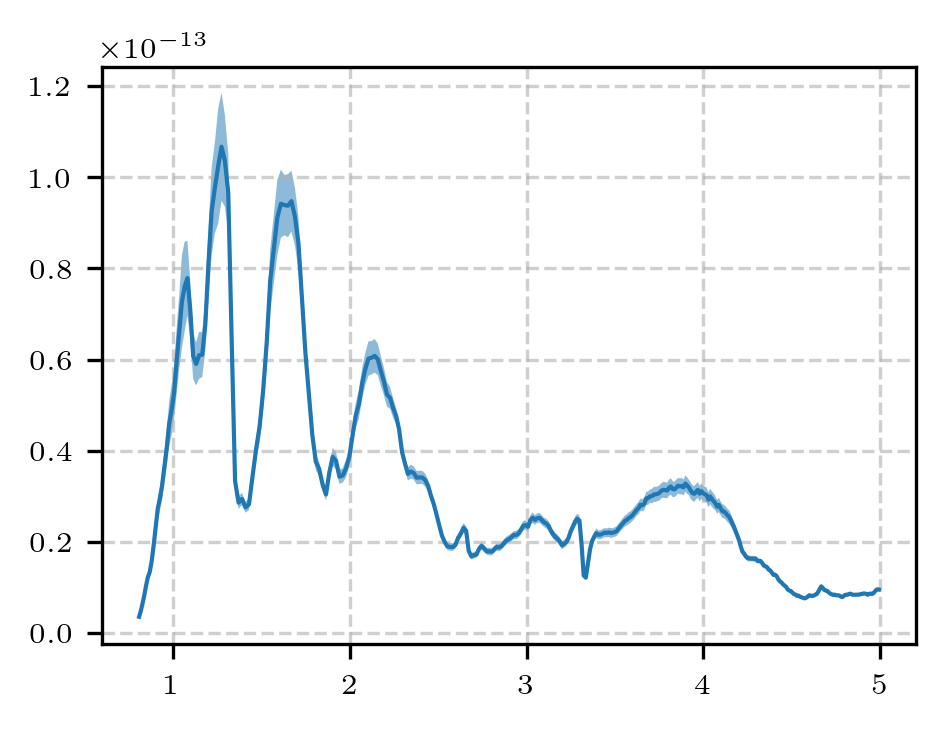

In [5]:
import matplotlib.pyplot as plt

spatial_spectra = maps.spatial_spectra
spatial_spectra_cov = maps.spatial_spectra_cov
spatial_spectra_std = np.sqrt(np.diagonal(spatial_spectra_cov, axis1=1, axis2=2))
i_grid = -1
plt.plot(wl[:], spatial_spectra[:, i_grid])
plt.fill_between(wl[:], spatial_spectra[:, i_grid] - spatial_spectra_std[:, i_grid], spatial_spectra[:, i_grid] + spatial_spectra_std[:, i_grid], alpha=0.5)

## 4. Clustering and Regional Identification
To make sense of the map, we group surface areas that show similar spectral behavior using a clustering algorithm. This helps us identify distinct regions or features on the object's surface. Averaging spatial spectra within these regions gives us regional spectra, which are accessible through the Maps object.

-1 399
0 100
1 100
2 100


(<Figure size 2100x750 with 1 Axes>,
 <Axes: title={'center': 'Classification in PC Space (100 neighbors)'}, xlabel='PC 1', ylabel='PC 2'>)

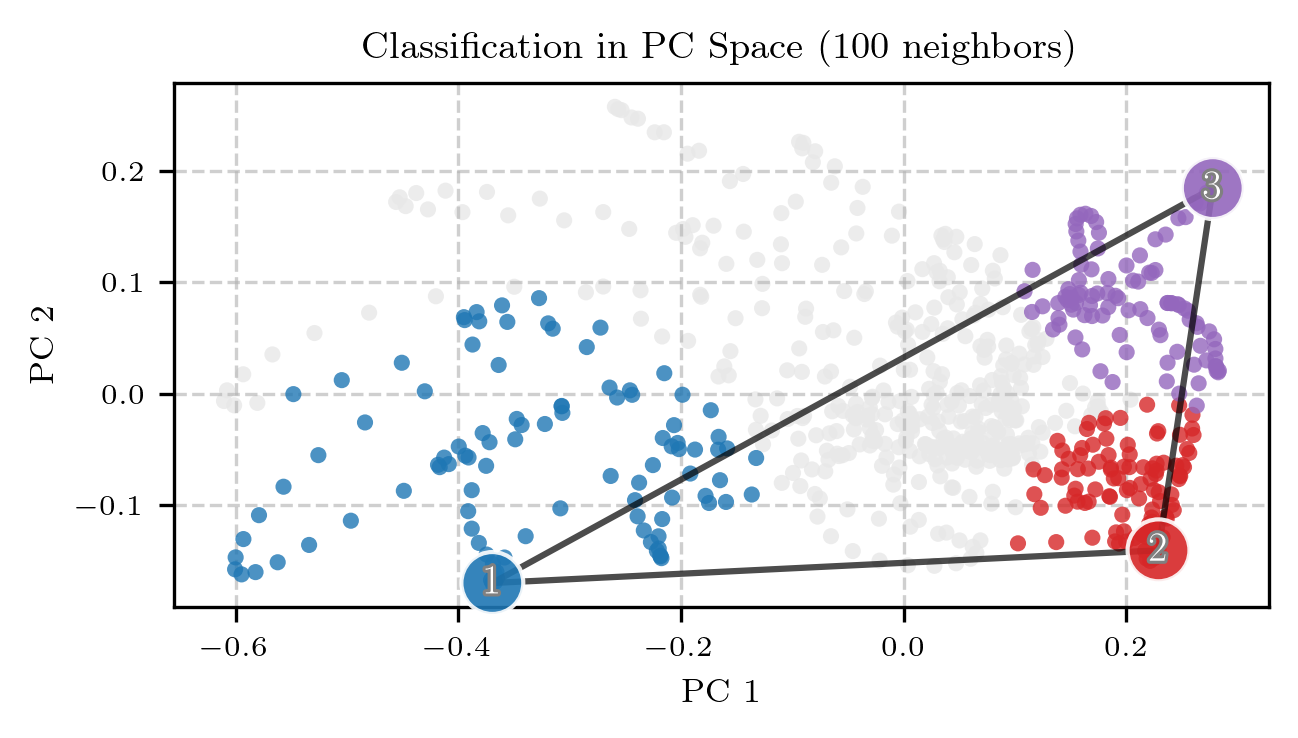

In [6]:
maps.find_clusters(n_neighbors=100, n_corners=3, plot=True)

## 5. Results
Finally, we visualize the identified regions on the map and plot the regional spectra.

(<Figure size 3600x1800 with 1 Axes>,
 <MollweideAxes: title={'center': 'PC1 and PC2 Overlay'}>)

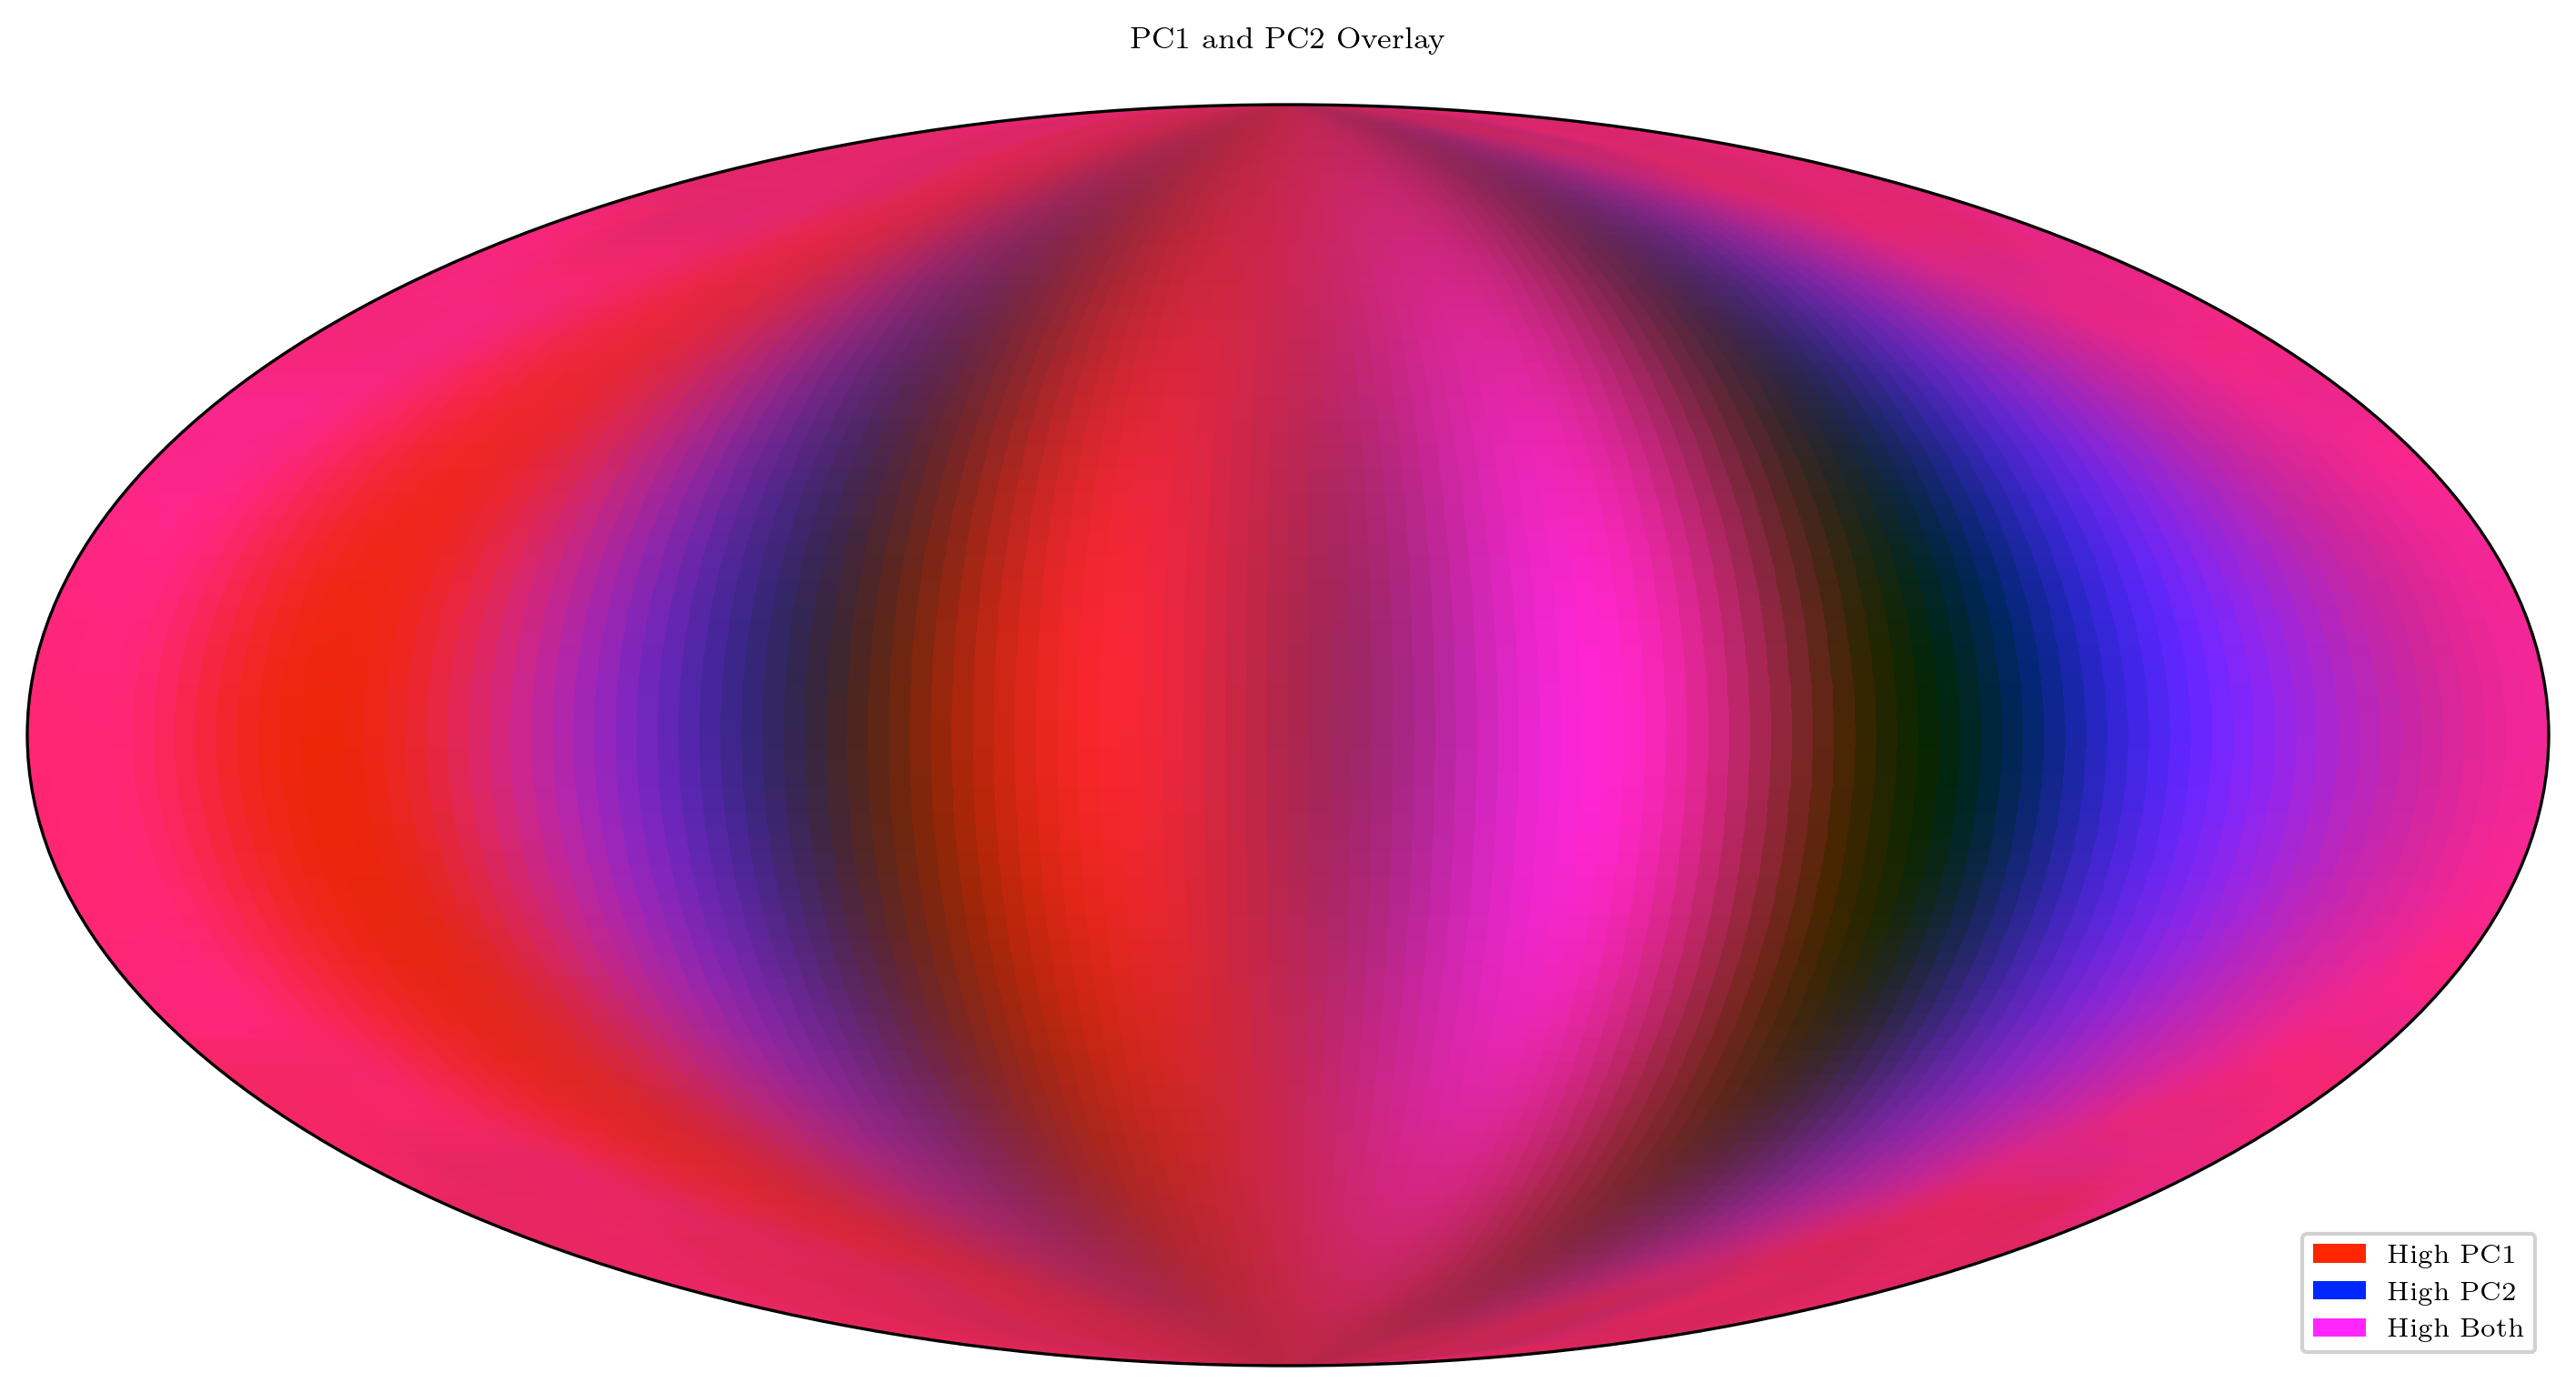

In [7]:
from spectralmap.plotting import plot_pc_projection, plot_labels, plot_spectra
plot_pc_projection(maps)

(<Figure size 2400x1350 with 2 Axes>,
 <MollweideAxes: xlabel='Longitude (deg)', ylabel='Latitude (deg)'>,
 <matplotlib.colorbar.Colorbar at 0x3356d7910>)

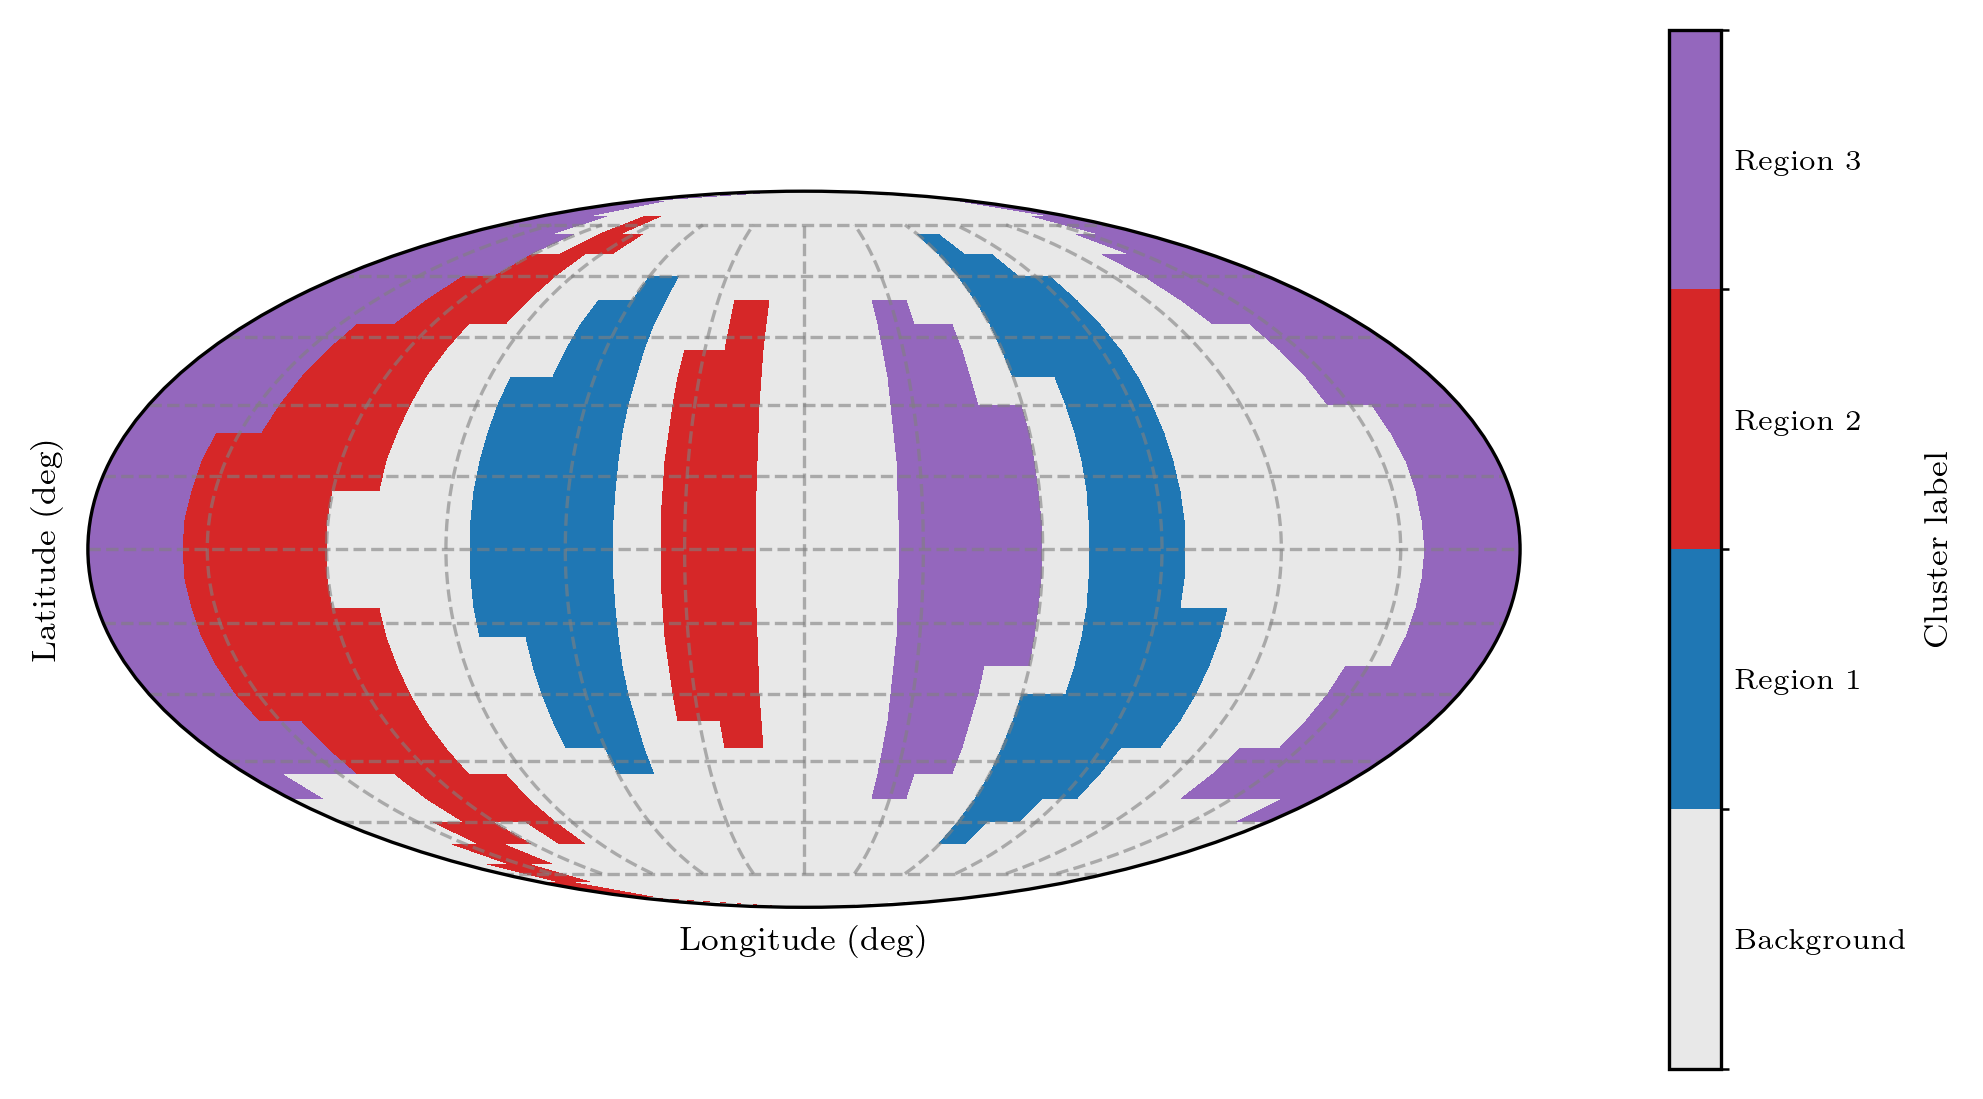

In [8]:
plot_labels(maps)

(<Figure size 2100x1500 with 2 Axes>,
 array([<Axes: title={'center': 'Recovered Regional Spectra'}, ylabel='Flux (W/m$^2$/$\\mu$m)'>,
        <Axes: xlabel='Wavelength ($\\mu$m)', ylabel='F/$F_{\\rm{mean}}$'>],
       dtype=object))

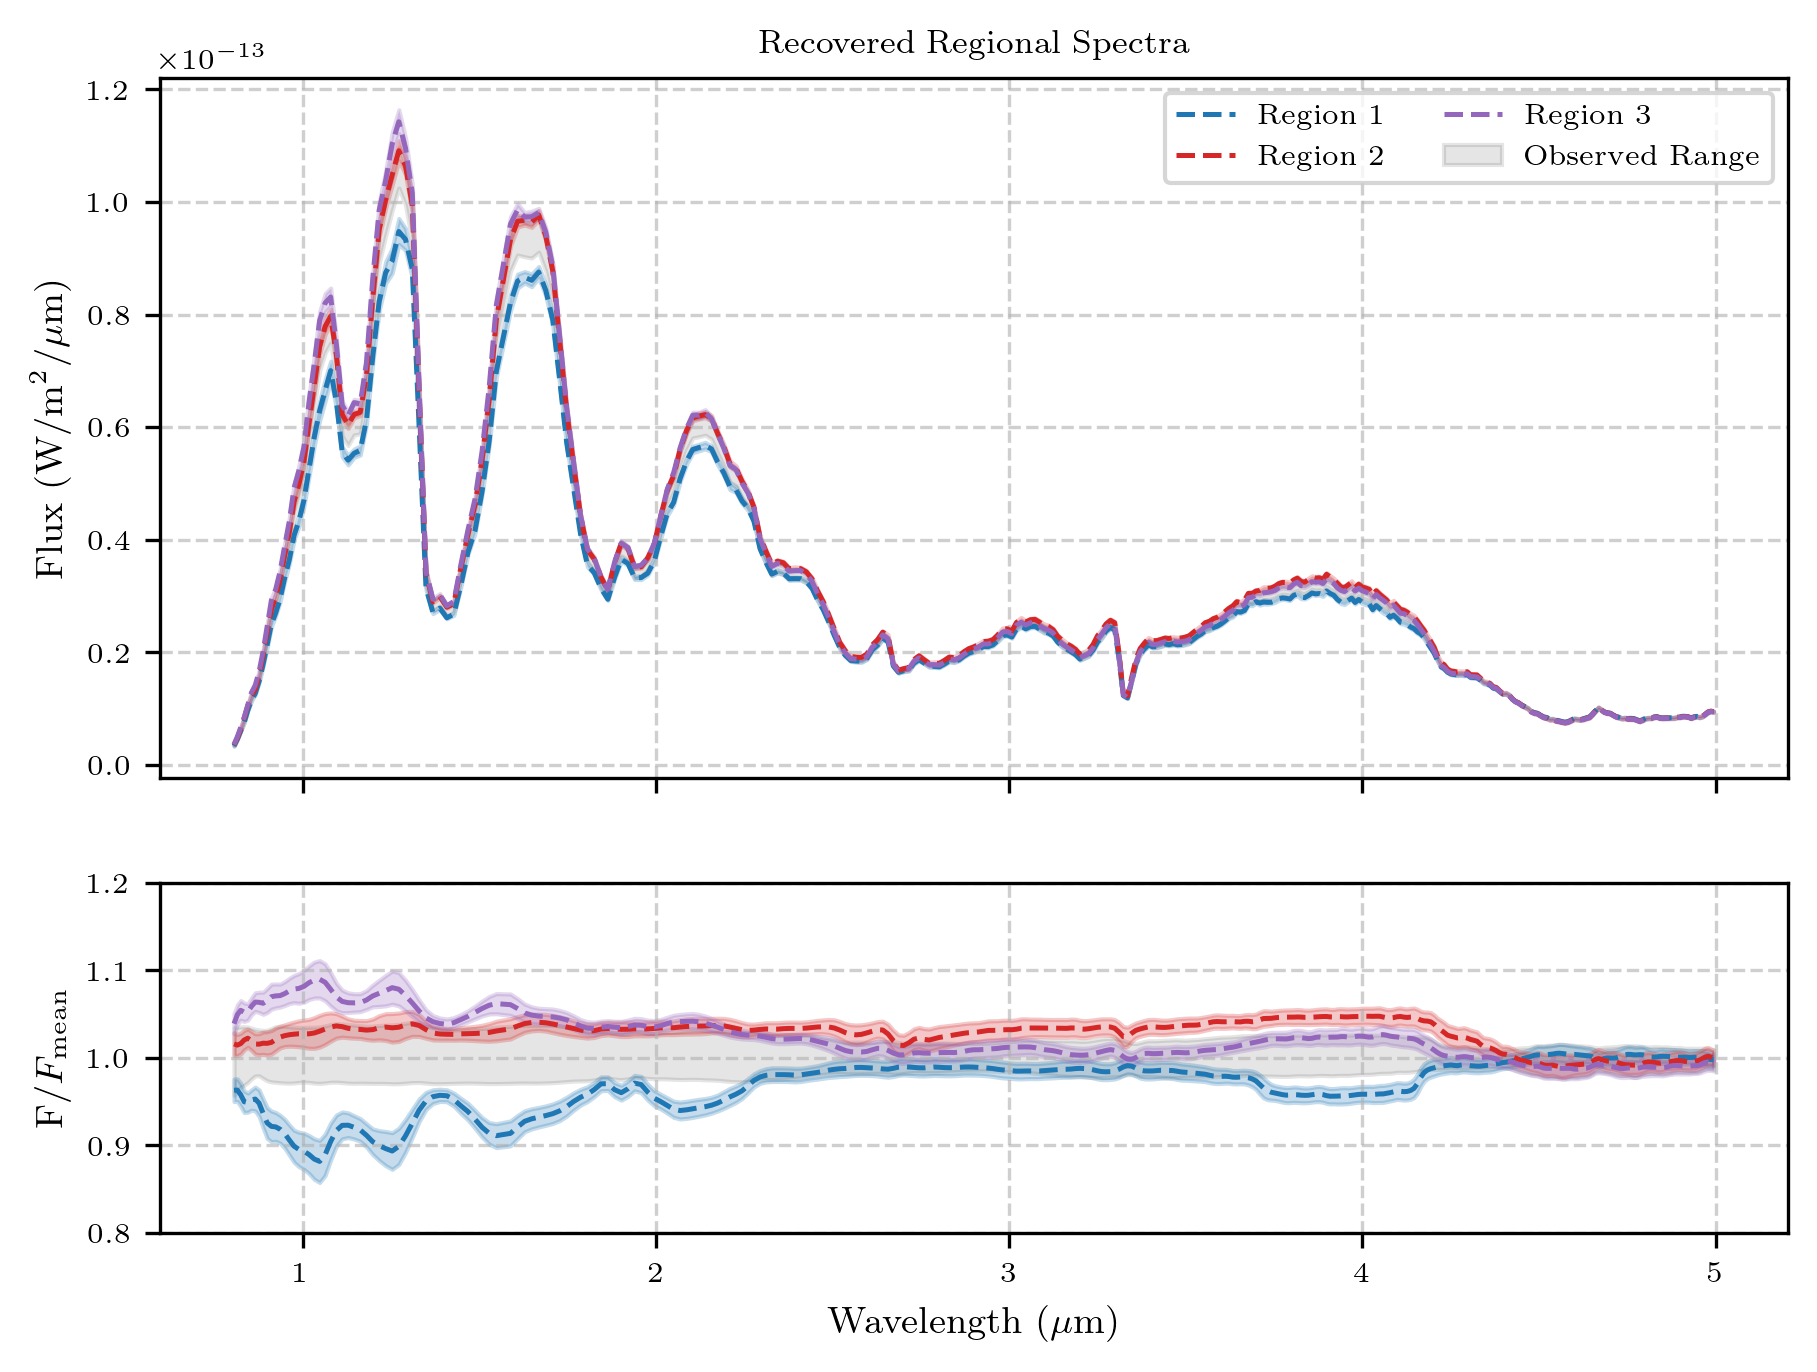

In [9]:
plot_spectra(maps)